<a href="https://colab.research.google.com/github/zaibjahan200/Deep-Learning-with-Models/blob/main/fashion_MNIST_app_with_model/Fashion_MNIST.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Data Loading and Preprocessing

First, we load the Fashion MNIST dataset using Keras. The dataset consists of 60,000 training images and 10,000 test images, each a 28x28 grayscale image, along with their labels.

We then inspect the initial shapes of the training images (`X_train`) and labels (`y_train`).

Following that, the 28x28 images are reshaped into 1-dimensional vectors of 784 pixels (`28 * 28`). This is a common step for fully connected neural networks. Finally, the pixel values, which are originally in the range of 0-255, are normalized to a range of 0-1 by dividing by 255. This helps in faster and more stable training of the neural network.

In [1]:
from tensorflow.keras.datasets import fashion_mnist as fm
import keras
from keras.models import Sequential
from keras.layers import Dense

(X_train,y_train),(X_test,y_test) = fm.load_data()

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [2]:
import numpy as np
print(X_train.shape)
print(y_train.shape)

(60000, 28, 28)
(60000,)


Normalize

In [3]:
# flatten images into one-dimensional vector

num_pixels = X_train.shape[1] * X_train.shape[2]

X_train = X_train.reshape(X_train.shape[0], num_pixels).astype('float32')
X_test = X_test.reshape(X_test.shape[0], num_pixels).astype('float32')

In [4]:
X_train = X_train / 255
X_test = X_test / 255

## One-Hot Encoding of Labels

The labels (`y_train` and `y_test`) are initially integers representing the class (0-9). For training with a categorical cross-entropy loss function, these labels need to be converted into a one-hot encoded format. This means each label will become a vector where only the index corresponding to the class is 1, and all other elements are 0. We also determine the `num_class` which is the number of unique output classes.

In [5]:
from keras.utils import to_categorical
y_train = to_categorical(y_train)
y_test = to_categorical(y_test)

num_class = y_test.shape[1]

In [6]:
num_class

10

In [7]:
def class_model():
  model = Sequential()
  model.add(Dense(num_pixels,activation = "relu",input_shape=(num_pixels,)))
  model.add(Dense(100, activation = "relu" ))
  model.add(Dense(num_class, activation = "softmax" ))

  model.compile(loss='categorical_crossentropy',optimizer='adam',metrics=['accuracy'])
  return model

## Model Definition

This section defines the neural network model using Keras's `Sequential` API. The model consists of three `Dense` (fully connected) layers:

1.  **Input Layer**: A `Dense` layer with `num_pixels` (784) neurons and a `relu` activation function. It takes the flattened image data as input.
2.  **Hidden Layer**: Another `Dense` layer with 100 neurons and a `relu` activation function.
3.  **Output Layer**: A `Dense` layer with `num_class` (10) neurons and a `softmax` activation function. The `softmax` activation ensures that the output is a probability distribution over the 10 classes.

The model is then `compiled` using:
*   `loss='categorical_crossentropy'`: Appropriate for multi-class classification with one-hot encoded labels.
*   `optimizer='adam'`: An adaptive learning rate optimization algorithm.
*   `metrics=['accuracy']`: To monitor the accuracy during training.

In [8]:
model = class_model()
model.fit(X_train, y_train, epochs=7,validation_data=[X_test[1:1000],y_test[1:1000]],verbose=1)

model.evaluate(X_test,y_test,verbose=1)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/7
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 25s 11ms/step - accuracy: 0.8282 - loss: 0.4725 - val_accuracy: 0.8549 - val_loss: 0.3879
Epoch 2/7
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 20s 11ms/step - accuracy: 0.8672 - loss: 0.3574 - val_accuracy: 0.8699 - val_loss: 0.3685
Epoch 3/7
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 19s 10ms/step - accuracy: 0.8809 - loss: 0.3224 - val_accuracy: 0.8699 - val_loss: 0.3637
Epoch 4/7
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 20s 11ms/step - accuracy: 0.8902 - loss: 0.2976 - val_accuracy: 0.8879 - val_loss: 0.3160
Epoch 5/7
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 19s 10ms/step - accuracy: 0.8953 - loss: 0.2807 - val_accuracy: 0.8829 - val_loss: 0.3479
Epoch 6/7
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 22s 11ms/step - accuracy: 0.8994 - loss: 0.2652 - val_accuracy: 0.8809 - val_loss: 0.3684
Epoch 7/7
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 20s 11ms/step - accuracy: 0.9039 - loss: 0.2535 - val_accuracy: 0.8819 - val_loss: 0.3442
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8756 - loss: 0.3519


[0.35194113850593567, 0.8755999803543091]

In [9]:
model.save('mnist.keras')

## Prediction for an uploaded apparel image

In [10]:
!git clone https://github.com/zaibjahan200/Deep-Learning-with-Models.git
%cd Deep-Learning-with-Models/fashion_MNIST_app_with_model
!pwd
!cp mnist.keras "/content/mnist_github.keras"


Cloning into 'Deep-Learning-with-Models'...
remote: Enumerating objects: 108, done.
remote: Counting objects: 100% (108/108), done.
remote: Compressing objects: 100% (97/97), done.
remote: Total 108 (delta 42), reused 28 (delta 6), pack-reused 0 (from 0)
Receiving objects: 100% (108/108), 32.76 MiB | 29.97 MiB/s, done.
Resolving deltas: 100% (42/42), done.
/content/Deep-Learning-with-Models/fashion_MNIST_app_with_model
/content/Deep-Learning-with-Models/fashion_MNIST_app_with_model


In [11]:
!cp "/content/Deep-Learning-with-Models/fashion_MNIST_app_with_model/mnist.keras" "/content/mnist_github.keras"

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step


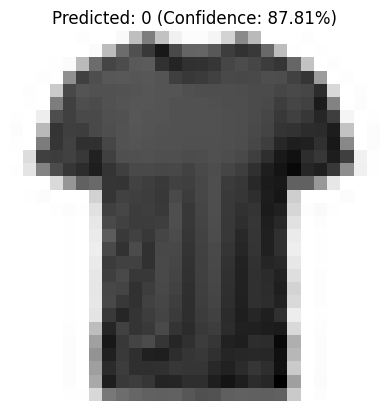

Predicted class index: 0


In [13]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import load_model
# Load your trained model
# model = load_model('fashion_mnist_87.keras')
model2 = load_model('/content/mnist.keras')
image_path = '/content/abc.jpg'
image = Image.open(image_path)

# ----- EXACT PREPROCESSING FROM STREAMLIT APP -----
# 1. Grayscale
img = image.convert("L")

# 2. Resize using LANCZOS (same as Streamlit)
img = img.resize((28, 28), Image.Resampling.LANCZOS)

# 3. Normalize to [0, 1]
img_array = np.array(img) / 255.0

# 4. Invert if background is light (EXACTLY as in Streamlit)
if np.mean(img_array) > 0.5:
    img_array = 1.0 - img_array

# 5. Flatten
img_for_prediction = img_array.reshape(1, 784)

# Predict
prediction = model2.predict(img_for_prediction)
predicted_class = np.argmax(prediction)
confidence = np.max(prediction)

# Display
plt.imshow(img_array, cmap=plt.cm.binary)
plt.title(f"Predicted: {predicted_class} (Confidence: {confidence:.2%})")
plt.axis('off')
plt.show()

print(f"Predicted class index: {predicted_class}")  # Should be 1 (Trouser)

## Interpreting the Prediction

To make the predicted class more understandable, we define a list `classes` that maps the numerical class indices (0-9) to their corresponding fashion item names. We then use the predicted numerical class (which was `8` in this case) to retrieve the human-readable label and print it.

In [14]:
classes = [
    "T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"
]
print(f'Predicted Output is {classes[predicted_class]}')

Predicted Output is T-shirt/top
